In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv(r"C:\Users\Dell\OneDrive\Desktop\MSSQL16.SQLEXPRESS\loan_risk_prediction_dataset (1).csv")

print(df.head())
print(df.shape)
print(df.info())

   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
0   56  48353.0     31258.0        675.0               20  Female   
1   69  57462.0     23262.0        586.0                6    Male   
2   46  44219.0     26530.0        781.0               26    Male   
3   32  56307.0     11531.0        549.0               11    Male   
4   60  37034.0     27871.0        500.0               19  Female   

     Education           City EmploymentType  LoanApproved  
0  High School        Houston     Unemployed             0  
1  High School  San Francisco  Self-Employed             0  
2          PhD        Houston  Self-Employed             1  
3          NaN       New York     Unemployed             0  
4  High School        Chicago     Unemployed             0  
(5000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age 

In [5]:
##Check missing values

print(df.isnull().sum())

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64


In [6]:
#Handling missing values

df['Education'] = df['Education'].fillna(df['Education'].mode()[0])

In [7]:
##Remove duplicates

df = df.drop_duplicates()

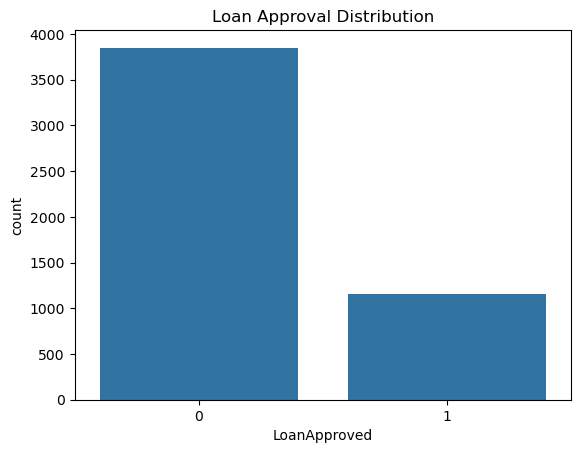

In [8]:
##Loan Approval Distribution

sns.countplot(x='LoanApproved', data=df)
plt.title('Loan Approval Distribution')
plt.show()

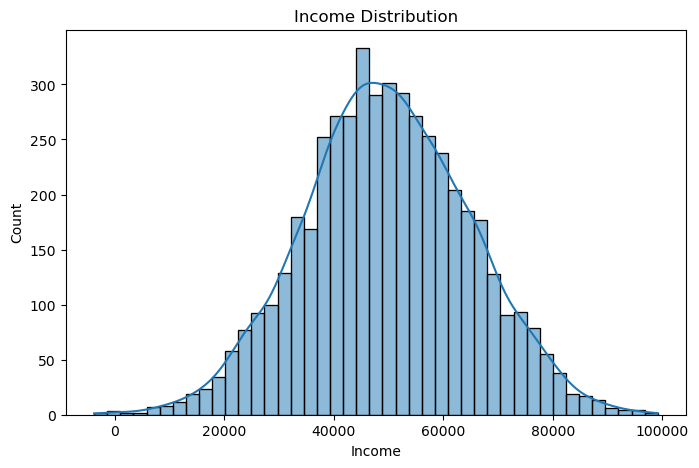

In [9]:
##Income Distribution 

plt.figure(figsize=(8,5))
sns.histplot(df['Income'], kde=True)
plt.title('Income Distribution')
plt.show()

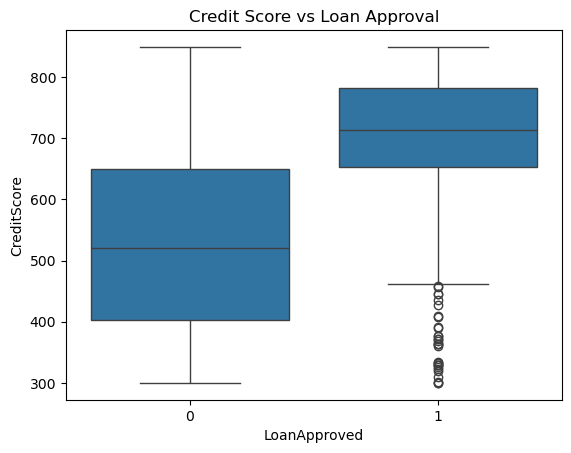

In [10]:
##Credit Scores Vs Loan approval 

sns.boxplot(x='LoanApproved', y='CreditScore', data=df)
plt.title('Credit Score vs Loan Approval')
plt.show()

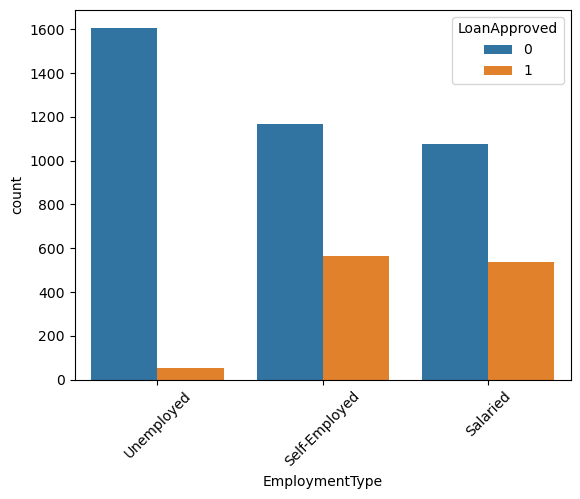

In [11]:
##Employment Type Analysis 

sns.countplot(x='EmploymentType', hue='LoanApproved', data=df)
plt.xticks(rotation=45)
plt.show()

In [12]:
##Convert Categorical Columns

le = LabelEncoder()

categorical_cols = ['Gender', 'Education', 'City', 'EmploymentType']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [13]:
##Define features and targets

X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

In [16]:
!pip install pandas sqlalchemy ipython-sql


   ---------- ----------------------------- 1/4 [sqlparse]
   -------------------- ------------------- 2/4 [prettytable]
   ---------------------------------------- 4/4 [ipython-sql]



In [17]:
%load_ext sql

In [18]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Dell\OneDrive\Desktop\MSSQL16.SQLEXPRESS\loan_risk_prediction_dataset (1).csv")

df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [19]:
import sqlite3

conn = sqlite3.connect("loan_analysis.db")

In [20]:
##Store data to sql table 

df.to_sql(
    name='loan_data',
    con=conn,
    if_exists='replace',
    index=False
)

5000

In [21]:
%sql sqlite:///loan_analysis.db

In [30]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [31]:
%%sql

SELECT AVG(Income) AS Average_Income
FROM loan_data;

 * sqlite:///loan_analysis.db
Done.


Average_Income
49738.12302248127


In [32]:
%%sql

SELECT LoanApproved,
       COUNT(*) AS Total_Count
FROM loan_data
GROUP BY LoanApproved;

 * sqlite:///loan_analysis.db
Done.


LoanApproved,Total_Count
0,3849
1,1151


In [33]:
%%sql

SELECT EmploymentType,
       ROUND(AVG(LoanApproved) * 100, 2) AS Approval_Rate
FROM loan_data
GROUP BY EmploymentType
ORDER BY Approval_Rate DESC;

 * sqlite:///loan_analysis.db
Done.


EmploymentType,Approval_Rate
Salaried,33.29
Self-Employed,32.54
Unemployed,3.13


In [34]:
%%sql

SELECT City,
       COUNT(*) AS Approved_Loans
FROM loan_data
WHERE LoanApproved = 1
GROUP BY City
ORDER BY Approved_Loans DESC;

 * sqlite:///loan_analysis.db
Done.


City,Approved_Loans
Chicago,304
San Francisco,300
New York,278
Houston,269


In [35]:
%%sql

SELECT *
FROM loan_data
WHERE CreditScore < 600
AND LoanApproved = 0;

 * sqlite:///loan_analysis.db
Done.


Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
32,56307.0,11531.0,549.0,11,Male,None,New York,Unemployed,0
60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
56,None,6279.0,599.0,22,Male,PhD,New York,Unemployed,0
40,43415.0,2065.0,382.0,30,Female,High School,San Francisco,Self-Employed,0
28,42613.0,6356.0,597.0,18,Female,High School,San Francisco,Self-Employed,0
19,55388.0,24109.0,413.0,0,Female,PhD,Houston,Salaried,0
41,None,5867.0,466.0,12,Male,Bachelors,Houston,Unemployed,0
61,39521.0,13080.0,560.0,2,Female,Masters,Chicago,Unemployed,0
55,75575.0,8608.0,561.0,28,Female,High School,Chicago,Unemployed,0


In [36]:
%%sql

SELECT
    CASE
        WHEN Income < 30000 THEN 'Low Income'
        WHEN Income BETWEEN 30000 AND 70000 THEN 'Medium Income'
        ELSE 'High Income'
    END AS Income_Category,

    COUNT(*) AS Customers

FROM loan_data

GROUP BY Income_Category;

 * sqlite:///loan_analysis.db
Done.


Income_Category,Customers
High Income,639
Low Income,450
Medium Income,3911


In [37]:
result = %sql SELECT * FROM loan_data LIMIT 10

df_sql = result.DataFrame()

df_sql.head()

 * sqlite:///loan_analysis.db
Done.


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,None,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


<Axes: xlabel='EmploymentType'>

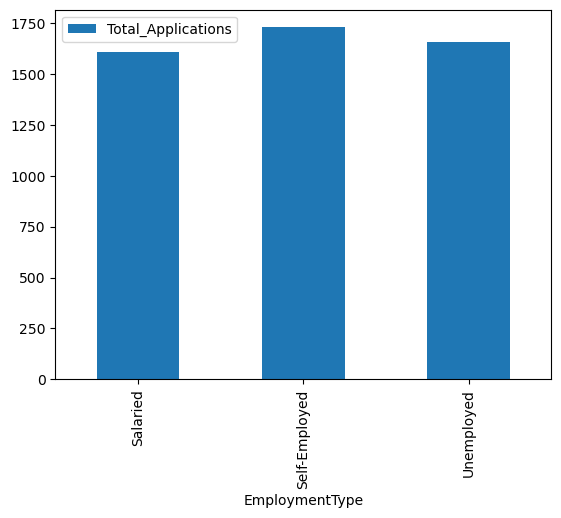

In [38]:
query = '''

SELECT EmploymentType,
       COUNT(*) AS Total_Applications
FROM loan_data
GROUP BY EmploymentType

'''

chart_df = pd.read_sql(query, conn)

chart_df.plot(
    x='EmploymentType',
    y='Total_Applications',
    kind='bar'
)

In [39]:
%%sql

SELECT COUNT(*) AS Total_Applications
FROM loan_data;

 * sqlite:///loan_analysis.db
Done.


Total_Applications
5000


In [40]:
%%sql

SELECT
ROUND(
    AVG(LoanApproved) * 100,
    2
) AS Approval_Rate
FROM loan_data;

 * sqlite:///loan_analysis.db
Done.


Approval_Rate
23.02


In [41]:
%%sql

SELECT AVG(CreditScore)
FROM loan_data;

 * sqlite:///loan_analysis.db
Done.


AVG(CreditScore)
575.4945900957136


In [42]:
%%sql

SELECT Education,
       COUNT(*) AS Rejected_Count
FROM loan_data
WHERE LoanApproved = 0
GROUP BY Education;

 * sqlite:///loan_analysis.db
Done.


Education,Rejected_Count
None,151
Bachelors,957
High School,924
Masters,919
PhD,898
